In [1]:
!pip install swig
!pip install gymnasium
!pip install box2d
!pip3 install box2d box2d-kengz

In [2]:
import gym
import matplotlib.pyplot as plt
import numpy as np

import torch
from torch import nn
from torch import optim
from torch.distributions.categorical import Categorical




In [3]:
DEVICE = 'cpu'
x=1

In [4]:
#policy and value
class ActorCriticNetwork(nn.Module):
    def __init__(self, obs_space_size=153, action_space_size=30):
        super(ActorCriticNetwork, self).__init__()

        self.shared_layers = nn.Sequential(
            nn.Linear(19, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU()
        )

        # Policy head
        self.policy_layers = nn.Sequential(
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, action_space_size),
            nn.Softmax(dim=-1)  # Softmax layer for discrete action space
        )

        # Value head
        self.value_layers = nn.Linear(64, 1)  # Output a single value

    def forward(self, obs):
        """
        Forward pass through the network.
        Args:
            obs: Observations/states from the environment.

        Returns:
            policy_logits: The logits for the policy (actions).
            value: The estimated value of the state.
        """
        shared_output = self.shared_layers(obs)

        policy_logits = self.policy_layers(shared_output)
        value = self.value_layers(shared_output)

        return policy_logits, value

    def policy(self, obs):
        """
        Computes the policy for given observations.
        Args:
            obs: Observations/states from the environment.

        Returns:
            A distribution over actions.
        """
        z = self.shared_layers(obs)
        policy_logits = self.policy_layers(z)
        return policy_logits

    def value(self, obs):
        """
        Computes the value of given observations.
        Args:
            obs: Observations/states from the environment.

        Returns:
            Estimated value of the state.
        """
        z = self.shared_layers(obs)
        value = self.value_layers(z)
        return value


In [5]:
class PPOTrainer():
    def __init__(self,
                 actor_critic,
                 ppo_clip_val=0.2,
                 target_kl_div=0.01,
                 max_policy_train_iters=80,
                 value_train_iters=80,
                 policy_lr=3e-4,
                 value_lr=1e-2):
        self.ac = actor_critic
        self.ppo_clip_val = ppo_clip_val
        self.target_kl_div = target_kl_div
        self.max_policy_train_iters = max_policy_train_iters
        self.value_train_iters = value_train_iters

        # Initialize optimizers for policy and value networks
        policy_params = list(self.ac.shared_layers.parameters()) + \
            list(self.ac.policy_layers.parameters())
        self.policy_optim = optim.Adam(policy_params, lr=policy_lr)

        value_params = list(self.ac.shared_layers.parameters()) + \
            list(self.ac.value_layers.parameters())
        self.value_optim = optim.Adam(value_params, lr=value_lr)

    def train_policy(self, obs, acts, old_log_probs, gaes):
        """
        Train the policy network.
        Args:
            obs: Observations from the environment.
            acts: Actions taken in the environment.
            old_log_probs: Log probabilities of the actions under the old policy.
            gaes: Generalized advantage estimations.
        """
        for _ in range(self.max_policy_train_iters):
            self.policy_optim.zero_grad()

            # Calculate new log probabilities of actions
            new_logits = self.ac.policy(obs)
            new_probs = Categorical(logits=new_logits)
            new_log_probs = new_probs.log_prob(acts)

            # Calculate policy ratio
            policy_ratio = torch.exp(new_log_probs - old_log_probs)
            clipped_ratio = policy_ratio.clamp(
                1 - self.ppo_clip_val, 1 + self.ppo_clip_val)

            # Calculate policy loss and perform backpropagation
            clipped_loss = clipped_ratio * gaes
            full_loss = policy_ratio * gaes
            policy_loss = -torch.min(full_loss, clipped_loss).mean()

            policy_loss.backward()
            self.policy_optim.step()

            # Early stopping based on KL divergence
            kl_div = (old_log_probs - new_log_probs).mean()
            if kl_div >= self.target_kl_div:
                break

    def train_value(self, obs, returns):
        """
        Train the value network.
        Args:
            obs: Observations from the environment.
            returns: Returns (cumulative rewards) to be used as targets for value estimation.
        """
        for _ in range(self.value_train_iters):
            self.value_optim.zero_grad()

            # Calculate value loss and perform backpropagation
            values = self.ac.value(obs)
            value_loss = (returns - values) ** 2
            value_loss = value_loss.mean()

            value_loss.backward()
            self.value_optim.step()

    @staticmethod
    def discount_rewards(rewards, gamma=0.95):
        discounted_rewards = np.zeros_like(rewards, dtype=np.float32)
        running_add = 0
        for t in reversed(range(len(rewards))):
            running_add = running_add * gamma + rewards[t]
            discounted_rewards[t] = running_add
        return discounted_rewards

        
    @staticmethod
    def calculate_gaes(rewards, values, gamma=0.95, lambda_=0.97):
        advantages = np.zeros_like(rewards, dtype=np.float32)
        gae = 0
        next_values = np.append(values[1:], 0)

        for t in reversed(range(len(rewards))):
            delta = rewards[t] + gamma * next_values[t] - values[t]
            gae = delta + gamma * lambda_ * gae
            advantages[t] = gae

        return advantages

    def rollout(model, env, max_steps=1000):
        obs = env.reset()
        ep_reward = 0
        train_data = {'obs': [], 'acts': [], 'rewards': [], 'values': [], 'log_probs': []}

        for step in range(max_steps):
            obs_tensor = torch.tensor([obs], dtype=torch.float32)
            logits, val = model(obs_tensor)
            act_distribution = Categorical(logits=logits)
            act = act_distribution.sample()
            act_log_prob = act_distribution.log_prob(act)

            next_obs, reward, done, _ = env.step(act.item())
            ep_reward += reward

            train_data['obs'].append(obs)
            train_data['acts'].append(act.item())
            train_data['rewards'].append(reward)
            train_data['values'].append(val.item())
            train_data['log_probs'].append(act_log_prob.item())

            obs = next_obs

            if done:
                break

        # Convert lists to numpy arrays for further processing
        for key in train_data.keys():
            train_data[key] = np.array(train_data[key])

        # Post-process rewards and values
        train_data['values'] = calculate_gaes(train_data['rewards'], train_data['values'])
        train_data['rewards'] = discount_rewards(train_data['rewards'])

        return train_data, ep_reward





In [6]:
import gym
from gym import spaces
import numpy as np
import random
from importlib import reload
import os
import pandas as pd
import pickle
import json

class SatelliteServiceEnv(gym.Env):
    def __init__(self, path_to='dataset_30/'):
        super(SatelliteServiceEnv, self).__init__()
        
        # Constants
        self.SATELLITE_NUM = 30
        self.SERVICE_NUM = 20000
        self.API_NUM = 900

        # Load and merge data
        self.path_to = path_to
        self.load_and_merge_data(self.path_to)

        
        # Initialize satellite data, service data, and API costs
        self.satellite_data = self.generate_satellite_data()
        self.service_data = self.generate_service_data()  # Make sure this line is present
        self.api_costs = self.generate_api_costs()

        # Example features per satellite and service
        features_per_satellite = 5 # Adjust as needed
        features_per_service = 3  # Adjust as needed

        # Total features in the observation space
        self.obs_space_size = features_per_satellite * self.SATELLITE_NUM + features_per_service
        self.observation_space = spaces.Box(low=0, high=200, shape=(self.obs_space_size,), dtype=np.float32)

        # Action Space
        self.action_space = spaces.Discrete(self.SATELLITE_NUM)

        self.state = None
        self.current_service = 0

    def load_and_merge_data(self, path_to='dataset_30'):
        if not isinstance(path_to, (str, bytes, os.PathLike)):
            raise ValueError(f"Invalid path: {path_to}")
        if not os.path.isdir(path_to):
            raise ValueError(f"Path is not a directory: {path_to}")

        for file in os.listdir(path_to):
            file_path = os.path.join(path_to, file)
            if os.path.isfile(file_path):
                if file.endswith(".csv"):
                    print(f"Processing CSV file: {file}")
                    data = pd.read_csv(file_path, header=None)
                    if file == 'api_info.csv':
                        self.api_data = data
                    elif file == 'satellite_api_cost.csv':
                        self.satellite_api_cost = data
                    elif file == 'satellite_api.csv':
                        self.satellite_api = data
                    elif file == 'service_api.csv':
                        self.service_api = data
                elif file.startswith("groundtruth") and file.endswith(".txt"):
                    print(f"Processing text file: {file}")
                    with open(file_path, 'r') as txt_file:
                        lines = txt_file.readlines()
                        for i in range(0, len(lines), 4):
                            api_list = json.loads(lines[i + 1].strip())
                            api_dict = json.loads(lines[i + 2].strip())
                            self.groundtruth_data.append({'api_list': api_list, 'api_dict': api_dict})

        pickle_path = os.path.join(path_to, "satellite_info.pickle")
        if os.path.exists(pickle_path):
            print("Loading satellite_info.pickle")
            with open(pickle_path, 'rb') as file:
                self.satellite_info = pickle.load(file)

    def generate_satellite_data(self):
        data = []
        for _ in range(self.SATELLITE_NUM):
            data.extend([
                random.uniform(75, 200),  
                random.uniform(40, 200),  
                random.uniform(2, 6),     
                random.uniform(50, 100),  
                random.uniform(20, 90)    
            ])
        return np.array(data)

    def generate_service_data(self):
        data = []
        for _ in range(self.SERVICE_NUM):
            data.extend([
                random.uniform(1, 75),   
                random.uniform(1, 40),   
                random.uniform(1, 5),    
                random.uniform(1, 20)    
            ])
        return np.array(data)

    def generate_api_costs(self):
        return np.random.uniform(1, 10, self.SATELLITE_NUM)

    def reset(self):
        self.current_service = 0
        self.allocated_services = set()
        self.satellite_data = self.generate_satellite_data()
        self.api_costs = self.generate_api_costs()
        self.state = self.get_current_state()
        return self.state

    # Modify the `get_current_state` method to reduce the observation space
    def get_current_state(self):
        # Including only essential features for the current satellite and service
        satellite_index = self.current_service % self.SATELLITE_NUM * 5
        service_index = self.current_service * 4
        satellite_data = self.satellite_data[satellite_index:satellite_index+5]
        service_data = self.service_data[service_index:service_index+4]
    
        # You may consider including a subset of API costs if relevant
        reduced_api_costs = self.api_costs[:10]  # Example: taking the first 10 costs

        return np.concatenate((satellite_data, service_data, reduced_api_costs))


    def step(self, action):
        satellite_index = action * 5
        service_index = self.current_service * 4
        satellite = self.satellite_data[satellite_index:satellite_index+5]
        service = self.service_data[service_index:service_index+4]

        valid_action = self.check_action_validity(action)
        done = False

        if valid_action:
            self.update_satellite_resources(action)
            reward = self.calculate_reward(action)
            self.allocated_services.add(self.current_service)
        else:
            reward = -10

        action_cost = self.api_costs[action]
        self.current_service += 1
        done = self.is_episode_over()
        self.state = self.get_current_state()
        return self.state, reward, done, action_cost

    def is_episode_over(self):
        if self.current_service >= self.SERVICE_NUM:
            return True
        if len(self.allocated_services) >= self.SERVICE_NUM:
            return True
        if not self.any_feasible_allocations_remaining():
            return True
        return False

    def any_feasible_allocations_remaining(self):
        for self.current_service in range(self.current_service, self.SERVICE_NUM):
            if self.current_service in self.allocated_services:
                continue

            service_index = self.current_service * 4
            service = self.service_data[service_index:service_index+4]

            for satellite_id in range(self.SATELLITE_NUM):
                satellite_index = satellite_id * 5
                satellite = self.satellite_data[satellite_index:satellite_index+5]

                if self.is_allocation_feasible(satellite, service):
                    return True
        return False

    def is_allocation_feasible(self, satellite, service):
        cpu_valid = service[0] <= satellite[0]
        memory_valid = service[1] <= satellite[1]
        delay_valid = service[2] >= satellite[2]
        energy_valid = service[3] <= satellite[3] * 0.2
        return cpu_valid and memory_valid and delay_valid and energy_valid

    def calculate_reward(self, action):
        satellite_index = action * 5
        service_index = self.current_service * 4
        satellite = self.satellite_data[satellite_index:satellite_index+5]
        service = self.service_data[service_index:service_index+4]

        # Initialize reward
        reward = 0

        # Define rewards and penalties for each constraint
        reward_for_cpu_compliance = 2
        penalty_for_cpu_violation = 5
        reward_for_memory_compliance = 2
        penalty_for_memory_violation = 5
        reward_for_delay_compliance = 2
        penalty_for_delay_violation = 5
        reward_for_energy_compliance = 2
        penalty_for_energy_violation = 5
        reward_for_temp_compliance = 2
        penalty_for_temp_violation = 5

        # Constraint 1: Service CPU <= Satellite CPU
        reward += reward_for_cpu_compliance if service[0] <= satellite[0] else -penalty_for_cpu_violation
    
        # Constraint 2: Service Memory <= Satellite Memory
        reward += reward_for_memory_compliance if service[1] <= satellite[1] else -penalty_for_memory_violation
    
        # Constraint 3: Service Delay >= Satellite Delay
        reward += reward_for_delay_compliance if service[2] >= satellite[2] else -penalty_for_delay_violation
    
        # Constraint 4: Service Energy <= Satellite Energy * 20%
        reward += reward_for_energy_compliance if service[3] <= satellite[3] * 0.2 else -penalty_for_energy_violation
    
        # Constraint 5: Satellite Temperature < 80 degrees
        reward += reward_for_temp_compliance if satellite[4] < 80 else -penalty_for_temp_violation

        # Cost Penalty: scaled based on API costs
        cost_penalty = self.api_costs[action]
        max_cost = max(self.api_costs)
        scaled_penalty = cost_penalty / max_cost * 10
        reward -= scaled_penalty

        return reward
    
    def check_action_validity(self, action):
        satellite_index = action * 5
        service_index = self.current_service * 4
        satellite = self.satellite_data[satellite_index:satellite_index+5]
        service = self.service_data[service_index:service_index+4]

        cpu_valid = service[0] <= satellite[0]
        memory_valid = service[1] <= satellite[1]
        delay_valid = service[2] >= satellite[2]
        energy_valid = service[3] <= satellite[3] * 0.2

        return cpu_valid and memory_valid and delay_valid and energy_valid

    def update_satellite_resources(self, action):
        satellite_index = action * 5
        service_index = self.current_service * 4
        service = self.service_data[service_index:service_index+4]

        self.satellite_data[satellite_index + 3] -= service[3]
        self.satellite_data[satellite_index] -= service[0]
        self.satellite_data[satellite_index + 1] -= service[1]
        self.api_costs[action] += 1

    def render(self, mode='console'):
        if mode == 'console':
            print(f"Current state: {self.state}")
            print(x)
            


In [7]:

# Initialize the environment
try:
    env = SatelliteServiceEnv(path_to='dataset_30/')
    state = env.reset()
    print(f"Size of state: {state.shape[0]}")
    
    # Print the dimension of the observation space
    print("Observation Space:", env.observation_space)
    print("Observation Space Shape:", env.observation_space.shape)

    # Print the dimension of the action space
    print("Action Space:", env.action_space)
    print("Number of Actions:", env.action_space.n if isinstance(env.action_space, gym.spaces.Discrete) else env.action_space.shape)
   
except Exception as e:
    print(f"Error creating environment: {e}")
    
# Initialize the ActorCriticNetwork and PPOTrainer
obs_space_size = env.observation_space.shape[0]
action_space_size = env.action_space.n
model = ActorCriticNetwork(obs_space_size, action_space_size)
ppo_trainer = PPOTrainer(model)

Processing CSV file: service_api.csv
Processing CSV file: satellite_api_cost.csv
Processing CSV file: api_info.csv
Processing CSV file: satellite_api.csv
Loading satellite_info.pickle
Size of state: 19
Observation Space: Box(0.0, 200.0, (153,), float32)
Observation Space Shape: (153,)
Action Space: Discrete(30)
Number of Actions: 30


In [8]:
env.reset()
for _ in range(200):
    env.render()
    observation, _, done, _ = env.step(env.action_space.sample())
    if done:
        
        break

env.close()

Current state: [177.38795454 141.04498369   2.0906398   93.52230069  88.05147538
  10.1069859    6.17017415   3.11108551  10.40350134   3.42125862
   8.86809598   8.52723346   1.12932102   9.96534264   8.00349331
   9.55627976   3.48024653   3.86997584   6.72488124]
1
Current state: [183.51765183 166.3318807    2.49821608  87.30346605  72.06163491
  37.93849514  14.8079526    2.812645     5.55920786   3.42125862
   8.86809598   8.52723346   1.12932102   9.96534264   8.00349331
   9.55627976   3.48024653   3.86997584   6.72488124]
1
Current state: [ 75.3318526  156.97484423   5.09840791  54.23339799  32.79646195
  74.24348517  36.19470689   2.50582066   5.15186967   3.42125862
   8.86809598   8.52723346   1.12932102   9.96534264   8.00349331
   9.55627976   3.48024653   3.86997584   6.72488124]
1
Current state: [142.97935498  91.19433745   3.65023024  96.82267907  75.50332312
   9.47097646  35.49247154   4.25977853   1.33161666   3.42125862
   8.86809598   8.52723346   1.12932102   9.96

In [9]:


# Training parameters
n_episodes = 1000  # Total number of training episodes
max_steps_per_episode = 1000  # Max steps per episode
print_freq = 10  # Frequency of printing the average reward

# Trackers for rewards
all_episode_rewards = []

for episode in range(n_episodes):
    # Reset environment and get initial state
    obs = env.reset()
    episode_reward = 0

    # Collect data from this episode
    episode_train_data = {'obs': [], 'acts': [], 'rewards': [], 'values': [], 'log_probs': []}

    for step in range(max_steps_per_episode):
        obs_tensor = torch.tensor([obs], dtype=torch.float32)
        
        # Get action logits and value from the model
        with torch.no_grad():
            action_logits, value = model(obs_tensor)

        # Sample action from the action distribution
        action_distribution = Categorical(logits=action_logits)
        action = action_distribution.sample()
        log_prob = action_distribution.log_prob(action)

        # Perform action in the environment
        new_obs, reward, done, _ = env.step(action.item())

        # Store data
        episode_train_data['obs'].append(obs)
        episode_train_data['acts'].append(action.item())
        episode_train_data['rewards'].append(reward)
        episode_train_data['values'].append(value.item())
        episode_train_data['log_probs'].append(log_prob.item())

        episode_reward += reward
        obs = new_obs

        if done:
            break

    all_episode_rewards.append(episode_reward)

    # Convert lists to numpy arrays for further processing
    for key in episode_train_data.keys():
        episode_train_data[key] = np.array(episode_train_data[key])

    # Calculate GAEs and discounted rewards
    gaes = ppo_trainer.calculate_gaes(episode_train_data['rewards'], episode_train_data['values'])
    discounted_rewards = ppo_trainer.discount_rewards(episode_train_data['rewards'])

    # Convert numpy arrays to torch tensors
    obs = torch.tensor(episode_train_data['obs'], dtype=torch.float32)
    acts = torch.tensor(episode_train_data['acts'], dtype=torch.int32)
    gaes = torch.tensor(gaes, dtype=torch.float32)
    old_log_probs = torch.tensor(episode_train_data['log_probs'], dtype=torch.float32)
    returns = torch.tensor(discounted_rewards, dtype=torch.float32)

    # Update policy and value networks
    ppo_trainer.train_policy(obs, acts, old_log_probs, gaes)
    ppo_trainer.train_value(obs, returns)

    # Print average reward every 'print_freq' episodes
    if (episode + 1) % print_freq == 0:
        avg_reward = sum(all_episode_rewards[-print_freq:]) / print_freq
        print(f"Episode {episode + 1}/{n_episodes}, Average Reward: {avg_reward}")

# Close the environment after training
env.close()


/var/folders/yd/49xl3hz50ts096s45hz_113m0000gn/T/ipykernel_4813/24818539.py:21: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:264.)
  obs_tensor = torch.tensor([obs], dtype=torch.float32)


Episode 10/1000, Average Reward: -8864.954147982357
Episode 20/1000, Average Reward: -8830.558558925684
Episode 30/1000, Average Reward: -8996.503721248722
Episode 40/1000, Average Reward: -9008.35888045061
Episode 50/1000, Average Reward: -9014.69102847955
Episode 60/1000, Average Reward: -8694.911994336844
Episode 70/1000, Average Reward: -8841.329454505993
Episode 80/1000, Average Reward: -8454.916353757088
Episode 90/1000, Average Reward: -9080.600020516058
Episode 100/1000, Average Reward: -8979.819437111795
Episode 110/1000, Average Reward: -8994.382098028076
Episode 120/1000, Average Reward: -9069.795405499448
Episode 130/1000, Average Reward: -9066.057084482136
Episode 140/1000, Average Reward: -8802.325041014057
Episode 150/1000, Average Reward: -9094.01746155479
Episode 160/1000, Average Reward: -8885.79066167463
Episode 170/1000, Average Reward: -9129.591763988466
Episode 180/1000, Average Reward: -8810.19482974968
Episode 190/1000, Average Reward: -8467.602473549803
Episode

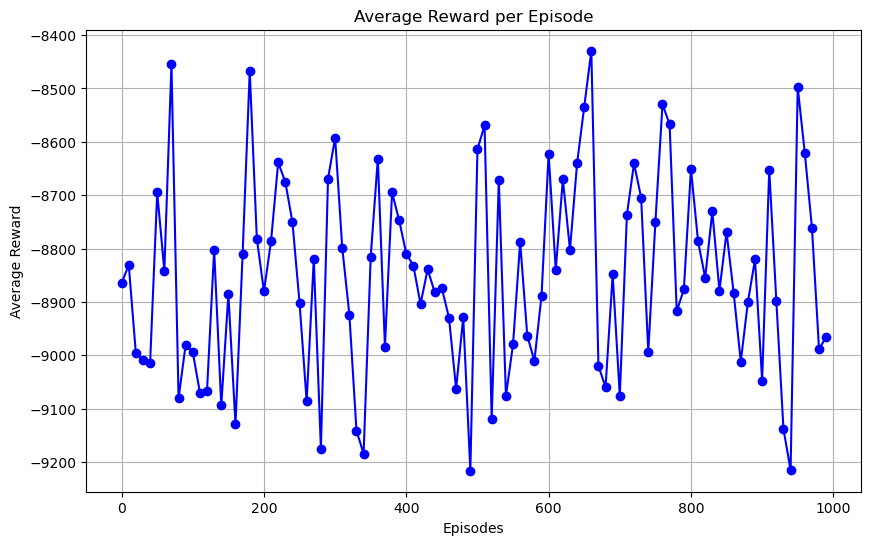

In [10]:
import matplotlib.pyplot as plt

# Assuming you have a list 'all_episode_rewards' containing the reward for each episode
# Let's say we want to plot the average reward over every 10 episodes

# Define the frequency for calculating the average reward
print_freq = 10  

# Calculate the average rewards over blocks of 'print_freq' episodes
average_rewards = [sum(all_episode_rewards[i:i+print_freq]) / print_freq for i in range(0, len(all_episode_rewards), print_freq)]

# Generate episode markers for plotting
episodes = [i for i in range(0, len(all_episode_rewards), print_freq)]

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(episodes, average_rewards, marker='o', linestyle='-', color='b')
plt.title("Average Reward per Episode")
plt.xlabel("Episodes")
plt.ylabel("Average Reward")
plt.grid(True)
plt.show()
